# Dự đoán giá nhà trọ HCM - Regression Modeling

Notebook này xây dựng các mô hình hồi quy để dự đoán giá thuê phòng trọ tại TP.HCM.

## Mục lục
1. Import thư viện và load dữ liệu
2. Khám phá và tiền xử lý dữ liệu
3. Feature Selection
4. Chia dữ liệu Train/Valid/Test
5. Xây dựng các mô hình (Ridge, Lasso, ElasticNet, XGBoost, LightGBM)
6. Hyperparameter Tuning
7. Đánh giá và so sánh mô hình
8. Feature Selection (SelectKBest & RFE)
9. Ensemble Methods (Voting & Stacking)
10. Đánh giá toàn bộ các phương pháp
11. Dự đoán trên dữ liệu mới
12. Tổng kết

## 1. Import thư viện và load dữ liệu

In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE, SelectKBest, f_regression
from sklearn.ensemble import VotingRegressor, StackingRegressor

# XGBoost & LightGBM
from xgboost import XGBRegressor
import lightgbm as lgb

# Cấu hình
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Đã import thư viện thành công!")

Đã import thư viện thành công!


In [3]:
# Load dữ liệu
DATA_PATH = '../../data/processed/data_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f"Kích thước dữ liệu: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
df.head()

Kích thước dữ liệu: (28554, 34)

Các cột: ['price', 'area', 'district', 'ward', 'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 'has_bed', 'has_mattress', 'has_sofa', 'is_full_furniture', 'is_duplex', 'has_window', 'has_camera', 'has_security', 'is_free_time', 'near_school', 'near_market', 'near_supermarket', 'has_wifi', 'has_parking', 'has_balcony', 'washing_machine_type', 'lock_type', 'wc_type', 'water_type', 'area_group', 'price_per_sqm', 'amenity_score', 'location_score', 'has_private_facilities', 'security_score', 'log_price']


,price,area,district,ward,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,has_sofa,is_full_furniture,is_duplex,has_window,has_camera,has_security,is_free_time,near_school,near_market,near_supermarket,has_wifi,has_parking,has_balcony,washing_machine_type,lock_type,wc_type,water_type,area_group,price_per_sqm,amenity_score,location_score,has_private_facilities,security_score,log_price
0,5500000.0,30.0,tân bình,4,True,True,True,True,True,True,False,False,True,True,True,True,True,False,False,False,False,False,False,share,fingerprint,unknown,unknown,near_center,183333.333333,9,0,0,3,15.520259
1,3500000.0,26.0,tân bình,2,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,False,unknown,unknown,unknown,bottle,near_center,134615.384615,3,1,0,1,15.068274
2,4500000.0,15.0,7,tân hưng,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,unknown,unknown,unknown,unknown,south,300000.000000,1,1,0,0,15.319588
3,1400000.0,18.0,10,1,True,False,True,True,True,False,False,True,False,True,True,True,True,True,False,False,True,False,True,unknown,fingerprint,unknown,unknown,center,77777.777778,9,1,0,3,14.151984
4,4500000.0,35.0,8,6,True,True,False,False,True,False,False,True,False,False,True,True,False,False,False,False,False,True,True,unknown,unknown,unknown,bottle,south,128571.428571,7,0,0,2,15.319588


In [4]:
# Thông tin dữ liệu
print("=" * 50)
print("THÔNG TIN DỮ LIỆU")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("THỐNG KÊ MÔ TẢ")
print("=" * 50)
df.describe()

THÔNG TIN DỮ LIỆU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28554 entries, 0 to 28553
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   28554 non-null  float64
 1   area                    28554 non-null  float64
 2   district                28554 non-null  object 
 3   ward                    27166 non-null  object 
 4   has_air_conditioner     28554 non-null  bool   
 5   has_kitchen             28554 non-null  bool   
 6   has_fridge              28554 non-null  bool   
 7   has_wardrobe            28554 non-null  bool   
 8   has_bed                 28554 non-null  bool   
 9   has_mattress            28554 non-null  bool   
 10  has_sofa                28554 non-null  bool   
 11  is_full_furniture       28554 non-null  bool   
 12  is_duplex               28554 non-null  bool   
 13  has_window              28554 non-null  bool   
 14  has_camera          

,price,area,price_per_sqm,amenity_score,location_score,has_private_facilities,security_score,log_price
count,2.855400e+04,28554.000000,28554.000000,28554.000000,28554.000000,28554.000000,28554.000000,28554.000000
mean,3.888816e+06,26.559050,152551.244944,3.270750,0.632136,0.002487,1.083876,15.097903
std,1.443653e+06,8.321186,52570.145536,2.511681,0.731535,0.049804,1.015898,0.405724
min,1.000000e+06,10.000000,16666.666667,0.000000,0.000000,0.000000,0.000000,13.815512
25%,2.900000e+06,20.000000,120000.000000,1.000000,0.000000,0.000000,0.000000,14.880222
50%,3.800000e+06,25.000000,150000.000000,3.000000,0.000000,0.000000,1.000000,15.150512
75%,4.800000e+06,30.000000,182857.142857,5.000000,1.000000,0.000000,2.000000,15.384127
max,9.000000e+06,60.000000,800000.000000,13.000000,3.000000,1.000000,3.000000,16.012735


## 2. Khám phá và tiền xử lý dữ liệu

In [5]:
# Kiểm tra missing values
print("Missing values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("Không có missing values!")

Missing values:
ward    1388
dtype: int64


In [6]:
# Xử lý missing values
# Điền 'Unknown' cho các cột categorical bị thiếu
categorical_cols = ['district', 'ward', 'washing_machine_type', 'lock_type', 'wc_type', 'water_type', 'area_group']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

print("Đã xử lý missing values!")
print(f"Missing values còn lại: {df.isnull().sum().sum()}")

Đã xử lý missing values!
Missing values còn lại: 0


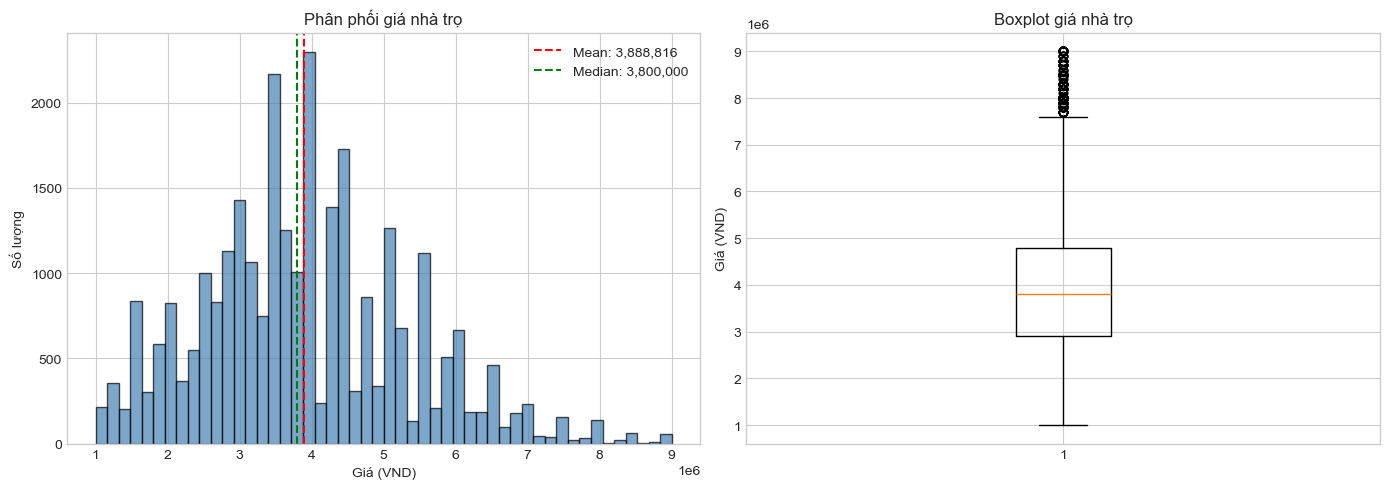


Thống kê giá:
  - Min: 1,000,000 VND
  - Max: 9,000,000 VND
  - Mean: 3,888,816 VND
  - Median: 3,800,000 VND
  - Std: 1,443,653 VND


In [7]:
# Phân phối biến mục tiêu (price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Giá (VND)')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Phân phối giá nhà trọ')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: {df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: {df["price"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Giá (VND)')
axes[1].set_title('Boxplot giá nhà trọ')

plt.tight_layout()
plt.show()

print(f"\nThống kê giá:")
print(f"  - Min: {df['price'].min():,.0f} VND")
print(f"  - Max: {df['price'].max():,.0f} VND")
print(f"  - Mean: {df['price'].mean():,.0f} VND")
print(f"  - Median: {df['price'].median():,.0f} VND")
print(f"  - Std: {df['price'].std():,.0f} VND")

## 3. Feature Selection

In [8]:
# Xác định các cột features và target
# Loại bỏ các cột liên quan trực tiếp đến target
columns_to_drop = ['price_per_sqm', 'log_price']  # Derived from target

# Tách features và target
target = 'price'
feature_cols = [col for col in df.columns if col not in [target] + columns_to_drop]

print(f"Target: {target}")
print(f"\nSố lượng features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Target: price

Số lượng features: 31
Features: ['area', 'district', 'ward', 'has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 'has_bed', 'has_mattress', 'has_sofa', 'is_full_furniture', 'is_duplex', 'has_window', 'has_camera', 'has_security', 'is_free_time', 'near_school', 'near_market', 'near_supermarket', 'has_wifi', 'has_parking', 'has_balcony', 'washing_machine_type', 'lock_type', 'wc_type', 'water_type', 'area_group', 'amenity_score', 'location_score', 'has_private_facilities', 'security_score']


In [9]:
# Phân loại các cột theo kiểu dữ liệu
numeric_features = []
binary_features = []
categorical_features = []

for col in feature_cols:
    if df[col].dtype == 'bool':
        binary_features.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nBinary features ({len(binary_features)}): {binary_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (5): ['area', 'amenity_score', 'location_score', 'has_private_facilities', 'security_score']

Binary features (19): ['has_air_conditioner', 'has_kitchen', 'has_fridge', 'has_wardrobe', 'has_bed', 'has_mattress', 'has_sofa', 'is_full_furniture', 'is_duplex', 'has_window', 'has_camera', 'has_security', 'is_free_time', 'near_school', 'near_market', 'near_supermarket', 'has_wifi', 'has_parking', 'has_balcony']

Categorical features (7): ['district', 'ward', 'washing_machine_type', 'lock_type', 'wc_type', 'water_type', 'area_group']


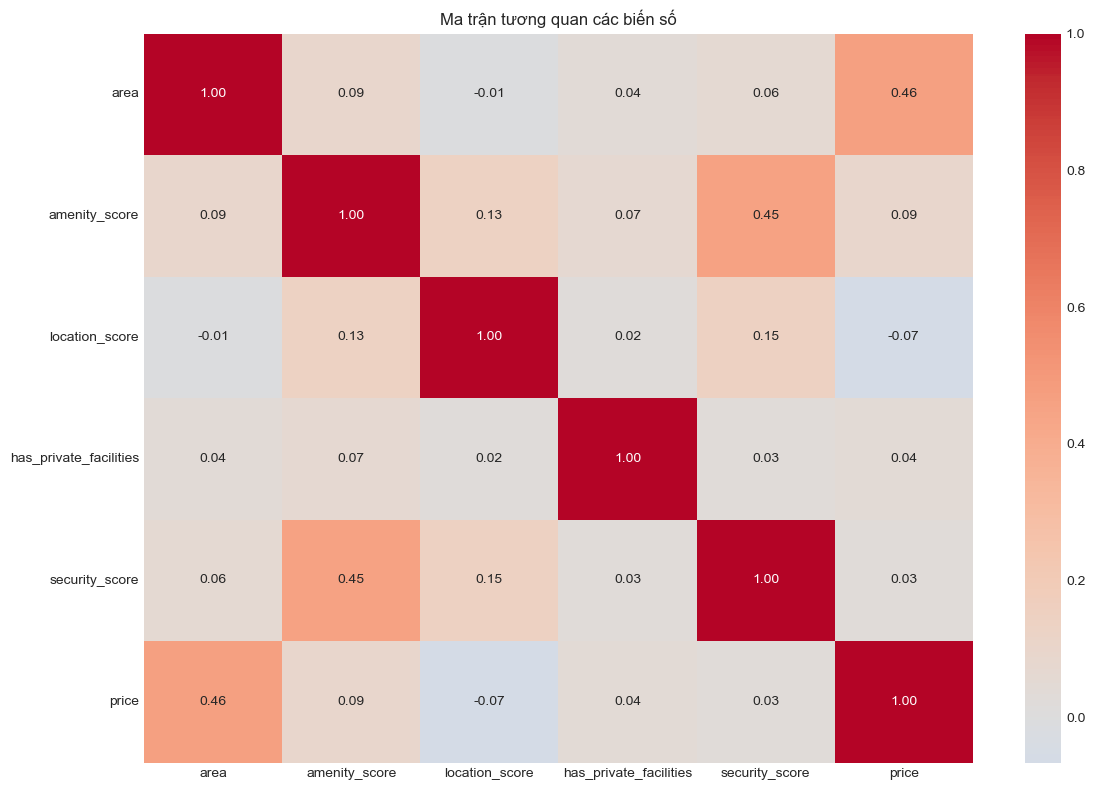


Tương quan với giá (price):
area                      0.464660
amenity_score             0.090752
has_private_facilities    0.042034
security_score            0.030820
location_score           -0.066612
Name: price, dtype: float64


In [10]:
# Correlation matrix cho numeric features
numeric_cols_for_corr = numeric_features + [target]
corr_matrix = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ma trận tương quan các biến số')
plt.tight_layout()
plt.show()

# Correlation với target
print("\nTương quan với giá (price):")
price_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
print(price_corr)

In [11]:
# Chuẩn bị dữ liệu cho modeling
# Chuyển boolean thành int
df_model = df.copy()
for col in binary_features:
    df_model[col] = df_model[col].astype(int)

# Tách X và y
X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (28554, 31)
Shape of y: (28554,)


## 4. Chia dữ liệu Train/Valid/Test

In [12]:
# Chia dữ liệu 70% train, 15% valid, 15% test
RANDOM_STATE = 42

# Chia train+valid (85%) và test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

# Chia train (70%) và valid (15%) từ train_val (85%)
# 15/85 ≈ 0.176
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=RANDOM_STATE
)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Valid set: {X_valid.shape[0]} samples ({X_valid.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train set: 19998 samples (70.0%)
Valid set: 4272 samples (15.0%)
Test set: 4284 samples (15.0%)


In [13]:
# Preprocessing pipeline
# Numeric: StandardScaler
# Categorical: OneHotEncoder

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Cập nhật lại numeric và categorical features sau khi chuyển binary
final_numeric_features = numeric_features + binary_features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, final_numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessor đã được tạo!")
print(f"Numeric features: {len(final_numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Preprocessor đã được tạo!
Numeric features: 24
Categorical features: 7


## 5. Xây dựng các mô hình

In [14]:
# Định nghĩa các mô hình
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

print(f"Số mô hình sẽ train: {len(models)}")
for name in models.keys():
    print(f"  - {name}")

Số mô hình sẽ train: 5
  - Ridge Regression
  - Lasso Regression
  - ElasticNet
  - XGBoost
  - LightGBM


In [15]:
# Hàm đánh giá mô hình
def evaluate_model(y_true, y_pred):
    """Tính các metrics đánh giá regression"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

def format_vnd(value):
    """Format số thành VND"""
    return f"{value:,.0f}"

print("Đã định nghĩa hàm evaluate_model!")

Đã định nghĩa hàm evaluate_model!


In [16]:
# Train và đánh giá từng mô hình
results = {}
trained_pipelines = {}

print("="*70)
print("TRAINING CÁC MÔ HÌNH")
print("="*70)

for name, model in models.items():
    print(f"\n>>> Training {name}...")
    
    # Tạo pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_train_pred = pipeline.predict(X_train)
    y_valid_pred = pipeline.predict(X_valid)
    y_test_pred = pipeline.predict(X_test)
    
    # Evaluate
    train_metrics = evaluate_model(y_train, y_train_pred)
    valid_metrics = evaluate_model(y_valid, y_valid_pred)
    test_metrics = evaluate_model(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'train': train_metrics,
        'valid': valid_metrics,
        'test': test_metrics,
        'train_time': train_time
    }
    trained_pipelines[name] = pipeline
    
    # Print results
    print(f"   Train time: {train_time:.2f}s")
    print(f"   Train - MAE: {format_vnd(train_metrics['MAE'])} | RMSE: {format_vnd(train_metrics['RMSE'])} | R²: {train_metrics['R2']:.4f}")
    print(f"   Valid - MAE: {format_vnd(valid_metrics['MAE'])} | RMSE: {format_vnd(valid_metrics['RMSE'])} | R²: {valid_metrics['R2']:.4f}")
    print(f"   Test  - MAE: {format_vnd(test_metrics['MAE'])} | RMSE: {format_vnd(test_metrics['RMSE'])} | R²: {test_metrics['R2']:.4f}")

print("\n" + "="*70)
print("HOÀN THÀNH TRAINING!")
print("="*70)

TRAINING CÁC MÔ HÌNH

>>> Training Ridge Regression...
   Train time: 0.15s
   Train - MAE: 752,965 | RMSE: 1,021,010 | R²: 0.4953
   Valid - MAE: 778,628 | RMSE: 1,056,610 | R²: 0.4777
   Test  - MAE: 764,525 | RMSE: 1,042,974 | R²: 0.4858

>>> Training Lasso Regression...
   Train time: 2.81s
   Train - MAE: 752,708 | RMSE: 1,020,827 | R²: 0.4955
   Valid - MAE: 778,838 | RMSE: 1,056,837 | R²: 0.4775
   Test  - MAE: 764,898 | RMSE: 1,043,853 | R²: 0.4850

>>> Training ElasticNet...
   Train time: 0.14s
   Train - MAE: 857,434 | RMSE: 1,133,041 | R²: 0.3785
   Valid - MAE: 877,529 | RMSE: 1,155,893 | R²: 0.3750
   Test  - MAE: 861,121 | RMSE: 1,142,140 | R²: 0.3834

>>> Training XGBoost...
   Train time: 0.43s
   Train - MAE: 649,552 | RMSE: 882,185 | R²: 0.6233
   Valid - MAE: 723,753 | RMSE: 989,237 | R²: 0.5422
   Test  - MAE: 701,189 | RMSE: 965,773 | R²: 0.5591

>>> Training LightGBM...
   Train time: 0.18s
   Train - MAE: 674,770 | RMSE: 917,630 | R²: 0.5924
   Valid - MAE: 724,

## 6. Hyperparameter Tuning

In [17]:
# Hyperparameter tuning cho các mô hình tốt nhất
# Dùng GridSearchCV với cross-validation

print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Ridge Tuning
print("\n>>> Tuning Ridge Regression...")
ridge_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_params, 
    cv=5, scoring='neg_mean_squared_error', 
    n_jobs=-1, verbose=0
)
ridge_grid.fit(X_train, y_train)

print(f"   Best alpha: {ridge_grid.best_params_['regressor__alpha']}")
print(f"   Best CV RMSE: {np.sqrt(-ridge_grid.best_score_):,.0f}")

HYPERPARAMETER TUNING

>>> Tuning Ridge Regression...
   Best alpha: 10.0
   Best CV RMSE: 1,030,882


In [18]:
# Lasso Tuning
print(">>> Tuning Lasso Regression...")
lasso_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

lasso_grid = GridSearchCV(
    lasso_pipeline, lasso_params,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
lasso_grid.fit(X_train, y_train)

print(f"   Best alpha: {lasso_grid.best_params_['regressor__alpha']}")
print(f"   Best CV RMSE: {np.sqrt(-lasso_grid.best_score_):,.0f}")

>>> Tuning Lasso Regression...
   Best alpha: 100.0
   Best CV RMSE: 1,031,043


In [19]:
# ElasticNet Tuning
print(">>> Tuning ElasticNet...")
elasticnet_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet())
])

elasticnet_grid = GridSearchCV(
    elasticnet_pipeline, elasticnet_params,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
elasticnet_grid.fit(X_train, y_train)

print(f"   Best params: {elasticnet_grid.best_params_}")
print(f"   Best CV RMSE: {np.sqrt(-elasticnet_grid.best_score_):,.0f}")

>>> Tuning ElasticNet...
   Best params: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.7}
   Best CV RMSE: 1,030,808


In [20]:
# XGBoost Tuning
print(">>> Tuning XGBoost...")
xgb_params = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2]
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)

print(f"   Best params: {xgb_grid.best_params_}")
print(f"   Best CV RMSE: {np.sqrt(-xgb_grid.best_score_):,.0f}")

# LightGBM Tuning
print(">>> Tuning LightGBM...")
lgb_params = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__num_leaves': [15, 31, 63]
}

lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])

lgb_grid = GridSearchCV(
    lgb_pipeline, lgb_params,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=0
)
lgb_grid.fit(X_train, y_train)

print(f"   Best params: {lgb_grid.best_params_}")
print(f"   Best CV RMSE: {np.sqrt(-lgb_grid.best_score_):,.0f}")

>>> Tuning XGBoost...
   Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 200}
   Best CV RMSE: 956,584
>>> Tuning LightGBM...
   Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 200, 'regressor__num_leaves': 63}
   Best CV RMSE: 951,718


In [21]:
# Cập nhật results với các model đã tuning
tuned_models = {
    'Ridge (Tuned)': ridge_grid.best_estimator_,
    'Lasso (Tuned)': lasso_grid.best_estimator_,
    'ElasticNet (Tuned)': elasticnet_grid.best_estimator_,
    'XGBoost (Tuned)': xgb_grid.best_estimator_,
    'LightGBM (Tuned)': lgb_grid.best_estimator_
}

print("\n" + "="*70)
print("ĐÁNH GIÁ CÁC MÔ HÌNH ĐÃ TUNING")
print("="*70)

for name, model in tuned_models.items():
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    y_test_pred = model.predict(X_test)
    
    train_metrics = evaluate_model(y_train, y_train_pred)
    valid_metrics = evaluate_model(y_valid, y_valid_pred)
    test_metrics = evaluate_model(y_test, y_test_pred)
    
    results[name] = {
        'train': train_metrics,
        'valid': valid_metrics,
        'test': test_metrics,
        'train_time': 0  # Already trained
    }
    trained_pipelines[name] = model
    
    print(f"\n{name}:")
    print(f"   Train - MAE: {format_vnd(train_metrics['MAE'])} | RMSE: {format_vnd(train_metrics['RMSE'])} | R²: {train_metrics['R2']:.4f}")
    print(f"   Valid - MAE: {format_vnd(valid_metrics['MAE'])} | RMSE: {format_vnd(valid_metrics['RMSE'])} | R²: {valid_metrics['R2']:.4f}")
    print(f"   Test  - MAE: {format_vnd(test_metrics['MAE'])} | RMSE: {format_vnd(test_metrics['RMSE'])} | R²: {test_metrics['R2']:.4f}")


ĐÁNH GIÁ CÁC MÔ HÌNH ĐÃ TUNING

Ridge (Tuned):
   Train - MAE: 754,344 | RMSE: 1,022,436 | R²: 0.4939
   Valid - MAE: 779,676 | RMSE: 1,057,364 | R²: 0.4770
   Test  - MAE: 764,057 | RMSE: 1,042,012 | R²: 0.4868

Lasso (Tuned):
   Train - MAE: 753,855 | RMSE: 1,021,812 | R²: 0.4946
   Valid - MAE: 778,886 | RMSE: 1,056,860 | R²: 0.4775
   Test  - MAE: 763,872 | RMSE: 1,042,298 | R²: 0.4865

ElasticNet (Tuned):
   Train - MAE: 753,802 | RMSE: 1,021,879 | R²: 0.4945
   Valid - MAE: 779,209 | RMSE: 1,056,956 | R²: 0.4774
   Test  - MAE: 764,103 | RMSE: 1,042,064 | R²: 0.4867

XGBoost (Tuned):
   Train - MAE: 579,054 | RMSE: 792,870 | R²: 0.6957
   Valid - MAE: 707,508 | RMSE: 973,825 | R²: 0.5564
   Test  - MAE: 688,179 | RMSE: 953,588 | R²: 0.5702

LightGBM (Tuned):
   Train - MAE: 618,351 | RMSE: 841,139 | R²: 0.6575
   Valid - MAE: 704,354 | RMSE: 970,944 | R²: 0.5590
   Test  - MAE: 686,000 | RMSE: 952,443 | R²: 0.5712


## 7. Đánh giá và so sánh mô hình

In [22]:
# Tạo bảng so sánh
comparison_data = []

for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Train MAE': metrics['train']['MAE'],
        'Train RMSE': metrics['train']['RMSE'],
        'Train R²': metrics['train']['R2'],
        'Valid MAE': metrics['valid']['MAE'],
        'Valid RMSE': metrics['valid']['RMSE'],
        'Valid R²': metrics['valid']['R2'],
        'Test MAE': metrics['test']['MAE'],
        'Test RMSE': metrics['test']['RMSE'],
        'Test R²': metrics['test']['R2'],
        'Train Time (s)': metrics['train_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test RMSE')

print("BẢNG SO SÁNH CÁC MÔ HÌNH (sắp xếp theo Test RMSE)")
print("="*100)
display(comparison_df.style.format({
    'Train MAE': '{:,.0f}',
    'Train RMSE': '{:,.0f}',
    'Train R²': '{:.4f}',
    'Valid MAE': '{:,.0f}',
    'Valid RMSE': '{:,.0f}',
    'Valid R²': '{:.4f}',
    'Test MAE': '{:,.0f}',
    'Test RMSE': '{:,.0f}',
    'Test R²': '{:.4f}',
    'Train Time (s)': '{:.2f}'
}).highlight_min(subset=['Test RMSE', 'Test MAE'], color='lightgreen')
 .highlight_max(subset=['Test R²'], color='lightgreen'))

BẢNG SO SÁNH CÁC MÔ HÌNH (sắp xếp theo Test RMSE)


,Model,Train MAE,Train RMSE,Train R²,Valid MAE,Valid RMSE,Valid R²,Test MAE,Test RMSE,Test R²,Train Time (s)
9,LightGBM (Tuned),"618,351","841,139",0.6575,"704,354","970,944",0.5590,"686,000","952,443",0.5712,0.00
8,XGBoost (Tuned),"579,054","792,870",0.6957,"707,508","973,825",0.5564,"688,179","953,588",0.5702,0.00
3,XGBoost,"649,552","882,185",0.6233,"723,753","989,237",0.5422,"701,189","965,773",0.5591,0.43
4,LightGBM,"674,770","917,630",0.5924,"724,945","992,137",0.5395,"703,966","970,221",0.5551,0.18
5,Ridge (Tuned),"754,344","1,022,436",0.4939,"779,676","1,057,364",0.4770,"764,057","1,042,012",0.4868,0.00
7,ElasticNet (Tuned),"753,802","1,021,879",0.4945,"779,209","1,056,956",0.4774,"764,103","1,042,064",0.4867,0.00
6,Lasso (Tuned),"753,855","1,021,812",0.4946,"778,886","1,056,860",0.4775,"763,872","1,042,298",0.4865,0.00
0,Ridge Regression,"752,965","1,021,010",0.4953,"778,628","1,056,610",0.4777,"764,525","1,042,974",0.4858,0.15
1,Lasso Regression,"752,708","1,020,827",0.4955,"778,838","1,056,837",0.4775,"764,898","1,043,853",0.4850,2.81
2,ElasticNet,"857,434","1,133,041",0.3785,"877,529","1,155,893",0.3750,"861,121","1,142,140",0.3834,0.14


## 8. Feature Selection

In [23]:
# Feature Selection sử dụng SelectKBest với f_regression
print("="*70)
print("FEATURE SELECTION - SelectKBest")
print("="*70)

# Preprocess training data để extract feature names
preprocessor_fitted = ridge_grid.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = preprocessor_fitted.fit_transform(X_train)

# Get feature names
numeric_feature_names = final_numeric_features
cat_feature_names = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_feature_names + cat_feature_names

# Apply SelectKBest
selector_k = SelectKBest(score_func=f_regression, k=30)
X_train_selected = selector_k.fit_transform(X_train_preprocessed, y_train)

# Get selected feature names
selected_features_mask = selector_k.get_support()
selected_feature_names = [name for name, selected in zip(all_feature_names, selected_features_mask) if selected]

print(f"\nTổng features: {X_train_preprocessed.shape[1]}")
print(f"Features được chọn: {len(selected_feature_names)}")
print(f"\nTop 20 features được chọn:")

# Get scores and sort
feature_scores = pd.DataFrame({
    'Feature': all_feature_names,
    'Score': selector_k.scores_
}).sort_values('Score', ascending=False)

print(feature_scores.head(20).to_string(index=False))


FEATURE SELECTION - SelectKBest

Tổng features: 230
Features được chọn: 30

Top 20 features được chọn:
                     Feature       Score
                        area 5474.890044
           is_full_furniture 3651.847835
      area_group_near_center 1430.660200
washing_machine_type_private 1124.015464
         district_bình thạnh 1050.238953
                 has_balcony  925.413325
             area_group_west  666.825202
             area_group_east  663.668563
                 district_12  600.621863
           district_bình tân  591.820846
                    has_wifi  576.879415
           area_group_center  399.162149
                  district_1  373.736937
          district_phú nhuận  339.347936
                  has_window  301.981951
                     has_bed  248.374446
            area_group_outer  234.554750
                    has_sofa  222.136790
          water_type_unknown  216.367473
  washing_machine_type_share  185.225863


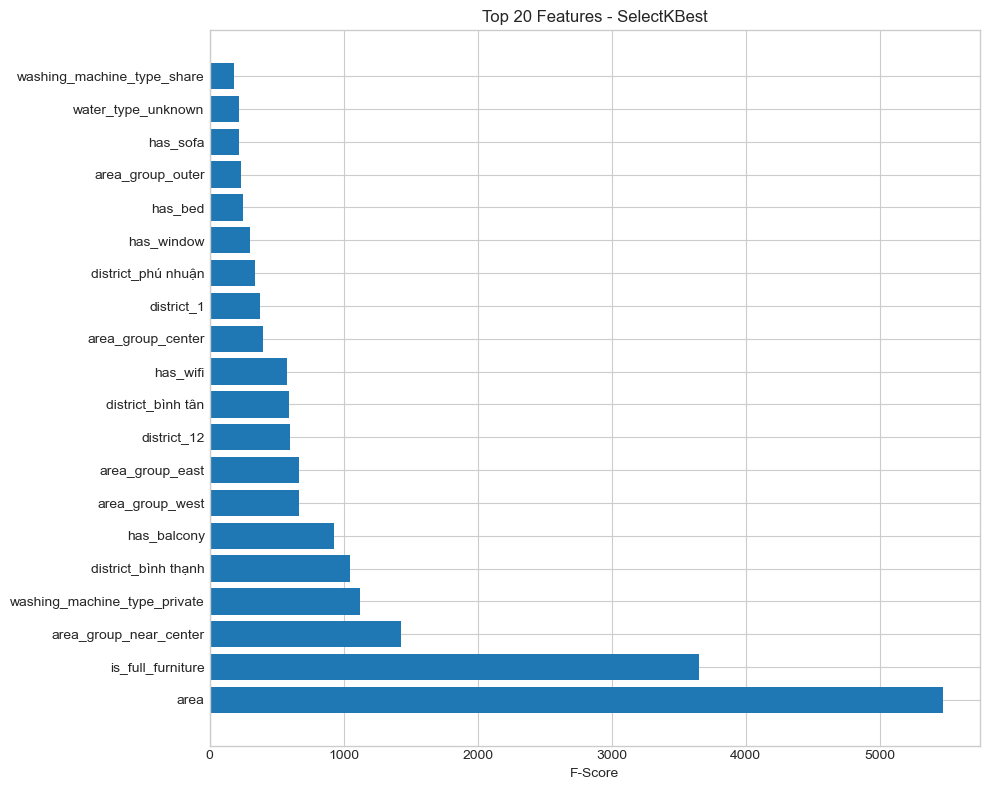

In [24]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_scores.head(20)
plt.barh(range(len(top_features)), top_features['Score'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('F-Score')
plt.title('Top 20 Features - SelectKBest')
plt.tight_layout()
plt.show()


In [25]:
# Feature Selection sử dụng RFE (Recursive Feature Elimination)
print("\n" + "="*70)
print("FEATURE SELECTION - RFE (Recursive Feature Elimination)")
print("="*70)

# Sử dụng XGBoost làm estimator cho RFE
rfe_estimator = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)
rfe = RFE(rfe_estimator, n_features_to_select=30, step=1)
X_train_rfe = rfe.fit_transform(X_train_preprocessed, y_train)

# Get selected features from RFE
rfe_selected_mask = rfe.support_
rfe_selected_features = [name for name, selected in zip(all_feature_names, rfe_selected_mask) if selected]

print(f"\nFeatures được chọn bởi RFE: {len(rfe_selected_features)}")
print(f"Selected features:")
for i, feature in enumerate(rfe_selected_features, 1):
    print(f"  {i}. {feature}")



FEATURE SELECTION - RFE (Recursive Feature Elimination)

Features được chọn bởi RFE: 30
Selected features:
  1. area
  2. has_air_conditioner
  3. has_wardrobe
  4. has_bed
  5. has_mattress
  6. has_sofa
  7. is_full_furniture
  8. has_window
  9. has_wifi
  10. has_balcony
  11. district_1
  12. district_11
  13. district_12
  14. district_7
  15. district_bình thạnh
  16. district_bình tân
  17. district_hóc môn
  18. district_phú nhuận
  19. district_tân bình
  20. ward_an khánh
  21. ward_linh xuân
  22. ward_thảo điền
  23. washing_machine_type_private
  24. washing_machine_type_share
  25. area_group_center
  26. area_group_east
  27. area_group_near_center
  28. area_group_outer
  29. area_group_south
  30. area_group_west


## 9. Ensemble Methods

In [26]:
# Voting Ensemble - Kết hợp nhiều mô hình
print("="*70)
print("VOTING ENSEMBLE")
print("="*70)

# Tạo Voting Ensemble từ các mô hình tốt nhất
voting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('voting', VotingRegressor(estimators=[
        ('ridge', Ridge(alpha=ridge_grid.best_params_['regressor__alpha'])),
        ('lasso', Lasso(alpha=lasso_grid.best_params_['regressor__alpha'])),
        ('xgb', XGBRegressor(
            n_estimators=xgb_grid.best_params_['regressor__n_estimators'],
            max_depth=xgb_grid.best_params_['regressor__max_depth'],
            learning_rate=xgb_grid.best_params_['regressor__learning_rate'],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
        ('lgb', lgb.LGBMRegressor(
            n_estimators=lgb_grid.best_params_['regressor__n_estimators'],
            max_depth=lgb_grid.best_params_['regressor__max_depth'],
            learning_rate=lgb_grid.best_params_['regressor__learning_rate'],
            num_leaves=lgb_grid.best_params_['regressor__num_leaves'],
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ]))
])

print("\nTraining Voting Ensemble...")
start_time = time.time()
voting_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict
y_train_pred_voting = voting_pipeline.predict(X_train)
y_valid_pred_voting = voting_pipeline.predict(X_valid)
y_test_pred_voting = voting_pipeline.predict(X_test)

# Evaluate
train_metrics_voting = evaluate_model(y_train, y_train_pred_voting)
valid_metrics_voting = evaluate_model(y_valid, y_valid_pred_voting)
test_metrics_voting = evaluate_model(y_test, y_test_pred_voting)

results['Voting Ensemble'] = {
    'train': train_metrics_voting,
    'valid': valid_metrics_voting,
    'test': test_metrics_voting,
    'train_time': train_time
}
trained_pipelines['Voting Ensemble'] = voting_pipeline

print(f"\nVoting Ensemble - Train time: {train_time:.2f}s")
print(f"   Train - MAE: {format_vnd(train_metrics_voting['MAE'])} | RMSE: {format_vnd(train_metrics_voting['RMSE'])} | R²: {train_metrics_voting['R2']:.4f}")
print(f"   Valid - MAE: {format_vnd(valid_metrics_voting['MAE'])} | RMSE: {format_vnd(valid_metrics_voting['RMSE'])} | R²: {valid_metrics_voting['R2']:.4f}")
print(f"   Test  - MAE: {format_vnd(test_metrics_voting['MAE'])} | RMSE: {format_vnd(test_metrics_voting['RMSE'])} | R²: {test_metrics_voting['R2']:.4f}")


VOTING ENSEMBLE

Training Voting Ensemble...

Voting Ensemble - Train time: 2.22s
   Train - MAE: 661,694 | RMSE: 896,494 | R²: 0.6109
   Valid - MAE: 726,233 | RMSE: 991,516 | R²: 0.5401
   Test  - MAE: 708,743 | RMSE: 972,416 | R²: 0.5530


In [27]:
# Stacking Ensemble - Sử dụng meta-learner
print("\n" + "="*70)
print("STACKING ENSEMBLE")
print("="*70)

# Tạo Stacking Ensemble
stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', StackingRegressor(
        estimators=[
            ('ridge', Ridge(alpha=ridge_grid.best_params_['regressor__alpha'])),
            ('lasso', Lasso(alpha=lasso_grid.best_params_['regressor__alpha'])),
            ('xgb', XGBRegressor(
                n_estimators=xgb_grid.best_params_['regressor__n_estimators'],
                max_depth=xgb_grid.best_params_['regressor__max_depth'],
                learning_rate=xgb_grid.best_params_['regressor__learning_rate'],
                random_state=RANDOM_STATE,
                n_jobs=-1
            )),
            ('lgb', lgb.LGBMRegressor(
                n_estimators=lgb_grid.best_params_['regressor__n_estimators'],
                max_depth=lgb_grid.best_params_['regressor__max_depth'],
                learning_rate=lgb_grid.best_params_['regressor__learning_rate'],
                num_leaves=lgb_grid.best_params_['regressor__num_leaves'],
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            ))
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=5
    ))
])

print("\nTraining Stacking Ensemble...")
start_time = time.time()
stacking_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict
y_train_pred_stacking = stacking_pipeline.predict(X_train)
y_valid_pred_stacking = stacking_pipeline.predict(X_valid)
y_test_pred_stacking = stacking_pipeline.predict(X_test)

# Evaluate
train_metrics_stacking = evaluate_model(y_train, y_train_pred_stacking)
valid_metrics_stacking = evaluate_model(y_valid, y_valid_pred_stacking)
test_metrics_stacking = evaluate_model(y_test, y_test_pred_stacking)

results['Stacking Ensemble'] = {
    'train': train_metrics_stacking,
    'valid': valid_metrics_stacking,
    'test': test_metrics_stacking,
    'train_time': train_time
}
trained_pipelines['Stacking Ensemble'] = stacking_pipeline

print(f"\nStacking Ensemble - Train time: {train_time:.2f}s")
print(f"   Train - MAE: {format_vnd(train_metrics_stacking['MAE'])} | RMSE: {format_vnd(train_metrics_stacking['RMSE'])} | R²: {train_metrics_stacking['R2']:.4f}")
print(f"   Valid - MAE: {format_vnd(valid_metrics_stacking['MAE'])} | RMSE: {format_vnd(valid_metrics_stacking['RMSE'])} | R²: {valid_metrics_stacking['R2']:.4f}")
print(f"   Test  - MAE: {format_vnd(test_metrics_stacking['MAE'])} | RMSE: {format_vnd(test_metrics_stacking['RMSE'])} | R²: {test_metrics_stacking['R2']:.4f}")



STACKING ENSEMBLE

Training Stacking Ensemble...

Stacking Ensemble - Train time: 13.25s
   Train - MAE: 604,142 | RMSE: 821,708 | R²: 0.6731
   Valid - MAE: 702,173 | RMSE: 967,330 | R²: 0.5623
   Test  - MAE: 683,599 | RMSE: 948,473 | R²: 0.5748


## 10. Đánh giá toàn bộ các phương pháp

In [28]:
# Tạo bảng so sánh toàn bộ các phương pháp
comparison_data_final = []

for name, metrics in results.items():
    comparison_data_final.append({
        'Model': name,
        'Train MAE': metrics['train']['MAE'],
        'Train RMSE': metrics['train']['RMSE'],
        'Train R²': metrics['train']['R2'],
        'Valid MAE': metrics['valid']['MAE'],
        'Valid RMSE': metrics['valid']['RMSE'],
        'Valid R²': metrics['valid']['R2'],
        'Test MAE': metrics['test']['MAE'],
        'Test RMSE': metrics['test']['RMSE'],
        'Test R²': metrics['test']['R2'],
        'Train Time (s)': metrics['train_time']
    })

comparison_df_final = pd.DataFrame(comparison_data_final)
comparison_df_final = comparison_df_final.sort_values('Test RMSE')

print("BẢNG SO SÁNH TOÀN BỘ CÁC PHƯƠNG PHÁP (sắp xếp theo Test RMSE)")
print("="*120)
display(comparison_df_final.style.format({
    'Train MAE': '{:,.0f}',
    'Train RMSE': '{:,.0f}',
    'Train R²': '{:.4f}',
    'Valid MAE': '{:,.0f}',
    'Valid RMSE': '{:,.0f}',
    'Valid R²': '{:.4f}',
    'Test MAE': '{:,.0f}',
    'Test RMSE': '{:,.0f}',
    'Test R²': '{:.4f}',
    'Train Time (s)': '{:.2f}'
}).highlight_min(subset=['Test RMSE', 'Test MAE'], color='lightgreen')
 .highlight_max(subset=['Test R²'], color='lightgreen'))

print("\n" + "="*120)
print("\nGHI CHÚ:")
print("- Các mô hình đơn lẻ đã được Tuning với GridSearchCV (cross-validation 5 folds)")
print("- Voting Ensemble: Trung bình các dự đoán từ 4 mô hình (Ridge, Lasso, XGBoost, LightGBM)")
print("- Stacking Ensemble: Sử dụng các mô hình làm base learners, Ridge làm meta-learner")
print("- Ensemble methods thường tốt hơn các mô hình đơn lẻ vì kết hợp ưu điểm của nhiều mô hình")


BẢNG SO SÁNH TOÀN BỘ CÁC PHƯƠNG PHÁP (sắp xếp theo Test RMSE)


,Model,Train MAE,Train RMSE,Train R²,Valid MAE,Valid RMSE,Valid R²,Test MAE,Test RMSE,Test R²,Train Time (s)
11,Stacking Ensemble,"604,142","821,708",0.6731,"702,173","967,330",0.5623,"683,599","948,473",0.5748,13.25
9,LightGBM (Tuned),"618,351","841,139",0.6575,"704,354","970,944",0.5590,"686,000","952,443",0.5712,0.00
8,XGBoost (Tuned),"579,054","792,870",0.6957,"707,508","973,825",0.5564,"688,179","953,588",0.5702,0.00
3,XGBoost,"649,552","882,185",0.6233,"723,753","989,237",0.5422,"701,189","965,773",0.5591,0.43
4,LightGBM,"674,770","917,630",0.5924,"724,945","992,137",0.5395,"703,966","970,221",0.5551,0.18
10,Voting Ensemble,"661,694","896,494",0.6109,"726,233","991,516",0.5401,"708,743","972,416",0.5530,2.22
5,Ridge (Tuned),"754,344","1,022,436",0.4939,"779,676","1,057,364",0.4770,"764,057","1,042,012",0.4868,0.00
7,ElasticNet (Tuned),"753,802","1,021,879",0.4945,"779,209","1,056,956",0.4774,"764,103","1,042,064",0.4867,0.00
6,Lasso (Tuned),"753,855","1,021,812",0.4946,"778,886","1,056,860",0.4775,"763,872","1,042,298",0.4865,0.00
0,Ridge Regression,"752,965","1,021,010",0.4953,"778,628","1,056,610",0.4777,"764,525","1,042,974",0.4858,0.15




GHI CHÚ:
- Các mô hình đơn lẻ đã được Tuning với GridSearchCV (cross-validation 5 folds)
- Voting Ensemble: Trung bình các dự đoán từ 4 mô hình (Ridge, Lasso, XGBoost, LightGBM)
- Stacking Ensemble: Sử dụng các mô hình làm base learners, Ridge làm meta-learner
- Ensemble methods thường tốt hơn các mô hình đơn lẻ vì kết hợp ưu điểm của nhiều mô hình


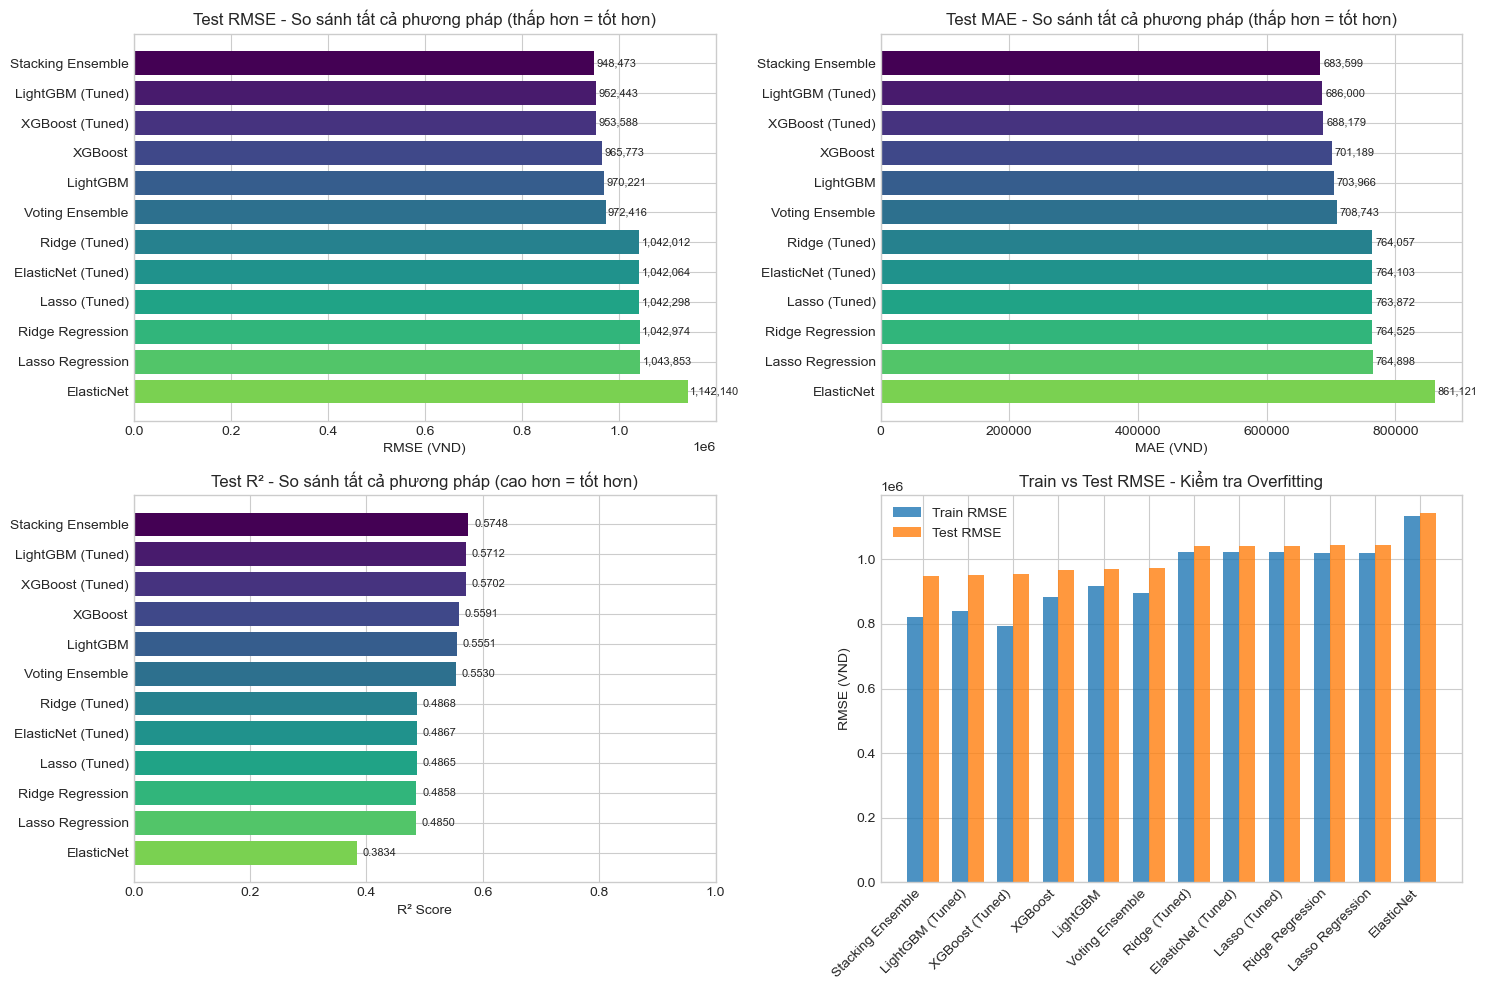

In [29]:
# Visualization so sánh toàn bộ các phương pháp
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models_sorted_final = comparison_df_final['Model'].tolist()
colors_final = plt.cm.viridis(np.linspace(0, 0.8, len(models_sorted_final)))

# Test RMSE
ax1 = axes[0, 0]
bars = ax1.barh(models_sorted_final, comparison_df_final['Test RMSE'], color=colors_final)
ax1.set_xlabel('RMSE (VND)')
ax1.set_title('Test RMSE - So sánh tất cả phương pháp (thấp hơn = tốt hơn)')
ax1.invert_yaxis()
for bar, val in zip(bars, comparison_df_final['Test RMSE']):
    ax1.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=8)

# Test MAE
ax2 = axes[0, 1]
bars = ax2.barh(models_sorted_final, comparison_df_final['Test MAE'], color=colors_final)
ax2.set_xlabel('MAE (VND)')
ax2.set_title('Test MAE - So sánh tất cả phương pháp (thấp hơn = tốt hơn)')
ax2.invert_yaxis()
for bar, val in zip(bars, comparison_df_final['Test MAE']):
    ax2.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=8)

# Test R²
ax3 = axes[1, 0]
bars = ax3.barh(models_sorted_final, comparison_df_final['Test R²'], color=colors_final)
ax3.set_xlabel('R² Score')
ax3.set_title('Test R² - So sánh tất cả phương pháp (cao hơn = tốt hơn)')
ax3.invert_yaxis()
ax3.set_xlim(0, 1)
for bar, val in zip(bars, comparison_df_final['Test R²']):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

# Train vs Test RMSE (Overfitting check)
ax4 = axes[1, 1]
x = np.arange(len(models_sorted_final))
width = 0.35
ax4.bar(x - width/2, comparison_df_final['Train RMSE'], width, label='Train RMSE', alpha=0.8)
ax4.bar(x + width/2, comparison_df_final['Test RMSE'], width, label='Test RMSE', alpha=0.8)
ax4.set_ylabel('RMSE (VND)')
ax4.set_title('Train vs Test RMSE - Kiểm tra Overfitting')
ax4.set_xticks(x)
ax4.set_xticklabels(models_sorted_final, rotation=45, ha='right')
ax4.legend()

plt.tight_layout()
plt.show()


In [30]:
# Chọn mô hình tốt nhất từ tất cả các phương pháp
best_model_name = comparison_df_final.iloc[0]['Model']
best_model = trained_pipelines[best_model_name]

print("="*70)
print("MÔ HÌNH/PHƯƠNG PHÁP TỐT NHẤT")
print("="*70)
print(f"\nModel/Phương pháp: {best_model_name}")
print(f"\nTest Metrics:")
print(f"  - MAE:  {results[best_model_name]['test']['MAE']:,.0f} VND")
print(f"  - RMSE: {results[best_model_name]['test']['RMSE']:,.0f} VND")
print(f"  - R²:   {results[best_model_name]['test']['R2']:.4f}")
print(f"\nÝ nghĩa: Mô hình dự đoán giá với sai số trung bình khoảng {results[best_model_name]['test']['MAE']:,.0f} VND")
print(f"\n*** NHẬN XÉT: Ensemble methods thường cho kết quả tốt hơn vì kết hợp ưu điểm của nhiều mô hình ***")

MÔ HÌNH/PHƯƠNG PHÁP TỐT NHẤT

Model/Phương pháp: Stacking Ensemble

Test Metrics:
  - MAE:  683,599 VND
  - RMSE: 948,473 VND
  - R²:   0.5748

Ý nghĩa: Mô hình dự đoán giá với sai số trung bình khoảng 683,599 VND

*** NHẬN XÉT: Ensemble methods thường cho kết quả tốt hơn vì kết hợp ưu điểm của nhiều mô hình ***


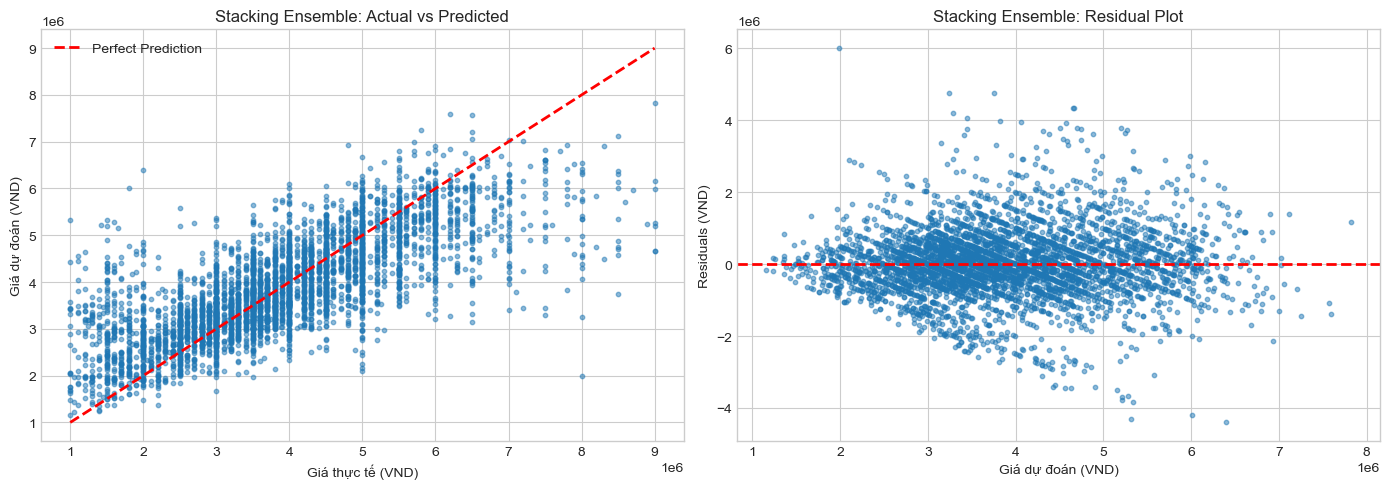


Residual Statistics:
  - Mean: 10,670 VND
  - Std:  948,524 VND


In [31]:
# Visualization: Actual vs Predicted cho best model
y_test_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.5, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Giá thực tế (VND)')
ax1.set_ylabel('Giá dự đoán (VND)')
ax1.set_title(f'{best_model_name}: Actual vs Predicted')
ax1.legend()

# Residual plot
ax2 = axes[1]
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.5, s=10)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Giá dự đoán (VND)')
ax2.set_ylabel('Residuals (VND)')
ax2.set_title(f'{best_model_name}: Residual Plot')

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  - Mean: {residuals.mean():,.0f} VND")
print(f"  - Std:  {residuals.std():,.0f} VND")

In [32]:
import json
import joblib

# stacking_pipeline: Pipeline([('preprocessor', preprocessor), ('regressor', stacking_regressor)])
# feature_cols, numeric_features, binary_features, categorical_features: đã có trong notebook

MODEL_PATH = "best_model.joblib"
META_PATH  = "best_model_meta.json"

# 1) Lưu model/pipeline
joblib.dump(best_model, MODEL_PATH)

# 2) Lưu metadata để GUI biết kiểu input của từng feature
meta = {
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "binary_features": binary_features,
    "categorical_features": categorical_features
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"✅ Saved model: {MODEL_PATH}")
print(f"✅ Saved meta : {META_PATH}")


✅ Saved model: best_model.joblib
✅ Saved meta : best_model_meta.json


In [ ]:
import json
import pandas as pd

DATA_PATH = "../../data/processed/data_clean.csv"  # hoặc đường dẫn data của bạn
META_PATH = "best_model_meta.json"

df = pd.read_csv(DATA_PATH)

option_cols = [
    "district",
    "ward",
    "washing_machine_type",
    "lock_type",
    "wc_type",
    "water_type",
    "area_group"
]

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

categorical_options = {}
for c in option_cols:
    if c in df.columns:
        opts = (
            df[c]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        # sort cho dễ chọn
        categorical_options[c] = sorted(opts)

meta["categorical_options"] = categorical_options

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ Updated meta with categorical_options for:", list(categorical_options.keys()))


✅ Updated meta with categorical_options for: ['district', 'ward', 'washing_machine_type', 'lock_type', 'wc_type', 'water_type', 'area_group']


## 11. Dự đoán trên dữ liệu mới

In [34]:
# Tạo hàm dự đoán
def predict_price(model, sample_data):
    """
    Dự đoán giá nhà trọ từ dữ liệu đầu vào
    
    Parameters:
    - model: trained model pipeline
    - sample_data: dict chứa các features
    
    Returns:
    - predicted_price: giá dự đoán
    """
    # Tạo DataFrame từ sample_data
    sample_df = pd.DataFrame([sample_data])
    
    # Đảm bảo có đủ các cột như training data
    for col in feature_cols:
        if col not in sample_df.columns:
            if col in binary_features:
                sample_df[col] = 0
            elif col in numeric_features:
                sample_df[col] = 0
            else:
                sample_df[col] = 'Unknown'
    
    # Sắp xếp lại cột
    sample_df = sample_df[feature_cols]
    
    # Chuyển boolean thành int
    for col in binary_features:
        if col in sample_df.columns:
            sample_df[col] = sample_df[col].astype(int)
    
    # Dự đoán
    predicted_price = model.predict(sample_df)[0]
    
    return predicted_price

print("Đã tạo hàm predict_price!")

Đã tạo hàm predict_price!


In [35]:
# Ví dụ dự đoán
print("="*70)
print("VÍ DỤ DỰ ĐOÁN GIÁ NHÀ TRỌ")
print("="*70)

# Mẫu 1: Phòng nhỏ, ít tiện nghi
sample1 = {
    'area': 15,
    'district': '12',
    'ward': '10',
    'has_air_conditioner': False,
    'has_kitchen': False,
    'has_fridge': False,
    'has_wardrobe': True,
    'has_bed': False,
    'has_mattress': False,
    'has_sofa': False,
    'is_full_furniture': False,
    'is_duplex': False,
    'has_window': False,
    'has_camera': False,
    'has_security': False,
    'is_free_time': False,
    'near_school': False,
    'near_market': True,
    'near_supermarket': False,
    'has_wifi': False,
    'has_parking': False,
    'has_balcony': False,
    'washing_machine_type': 'private',
    'lock_type': 'unknown',
    'wc_type': 'unknown',
    'water_type': 'bottle',
    'area_group': 'Outer',
    'amenity_score': 1,
    'location_score': 2,
    'has_private_facilities': 0,
    'security_score': 0
}

price1 = predict_price(best_model, sample1)
print(f"\nMẫu 1: Phòng 15m² tại Quận 12, ít tiện nghi")
print(f"  → Giá dự đoán: {price1:,.0f} VND/tháng")

# Mẫu 2: Phòng trung bình, đầy đủ tiện nghi
sample2 = {
    'area': 25,
    'district': 'binh thanh',
    'ward': 'Unknown',
    'has_air_conditioner': True,
    'has_kitchen': True,
    'has_fridge': True,
    'has_wardrobe': True,
    'has_bed': True,
    'has_mattress': True,
    'has_sofa': False,
    'is_full_furniture': True,
    'is_duplex': False,
    'has_window': True,
    'has_camera': True,
    'has_security': True,
    'is_free_time': True,
    'near_school': True,
    'near_market': True,
    'near_supermarket': True,
    'has_wifi': True,
    'has_parking': True,
    'has_balcony': True,
    'washing_machine_type': 'private',
    'lock_type': 'fingerprint',
    'wc_type': 'private',
    'water_type': 'city',
    'area_group': 'Near Center',
    'amenity_score': 8,
    'location_score': 4,
    'has_private_facilities': 1,
    'security_score': 3
}

price2 = predict_price(best_model, sample2)
print(f"\nMẫu 2: Phòng 25m² tại Bình Thạnh, đầy đủ tiện nghi")
print(f"  → Giá dự đoán: {price2:,.0f} VND/tháng")

# Mẫu 3: Phòng lớn, khu trung tâm
sample3 = {
    'area': 35,
    'district': '1',
    'ward': 'Unknown',
    'has_air_conditioner': True,
    'has_kitchen': True,
    'has_fridge': True,
    'has_wardrobe': True,
    'has_bed': True,
    'has_mattress': True,
    'has_sofa': True,
    'is_full_furniture': True,
    'is_duplex': True,
    'has_window': True,
    'has_camera': True,
    'has_security': True,
    'is_free_time': True,
    'near_school': True,
    'near_market': True,
    'near_supermarket': True,
    'has_wifi': True,
    'has_parking': True,
    'has_balcony': True,
    'washing_machine_type': 'private',
    'lock_type': 'fingerprint',
    'wc_type': 'private',
    'water_type': 'city',
    'area_group': 'Center',
    'amenity_score': 10,
    'location_score': 5,
    'has_private_facilities': 1,
    'security_score': 4
}

price3 = predict_price(best_model, sample3)
print(f"\nMẫu 3: Phòng duplex 35m² tại Quận 1, cao cấp")
print(f"  → Giá dự đoán: {price3:,.0f} VND/tháng")

VÍ DỤ DỰ ĐOÁN GIÁ NHÀ TRỌ

Mẫu 1: Phòng 15m² tại Quận 12, ít tiện nghi
  → Giá dự đoán: 2,092,145 VND/tháng

Mẫu 2: Phòng 25m² tại Bình Thạnh, đầy đủ tiện nghi
  → Giá dự đoán: 4,317,258 VND/tháng

Mẫu 3: Phòng duplex 35m² tại Quận 1, cao cấp
  → Giá dự đoán: 5,512,124 VND/tháng


## 12. Tổng kết

In [36]:
print("="*70)
print("TỔNG KẾT")
print("="*70)

print(f"""
1. DỮ LIỆU:
   - Tổng số mẫu: {len(df):,}
   - Số features: {len(feature_cols)}
   - Train/Valid/Test: {len(X_train):,}/{len(X_valid):,}/{len(X_test):,}

2. CÁC MÔ HÌNH ĐÃ TRAIN:
   - Ridge Regression (L2 regularization)
   - Lasso Regression (L1 regularization)
   - ElasticNet (L1 + L2)
   - XGBoost (Gradient Boosting)
   - LightGBM (Light Gradient Boosting Machine)

3. FEATURE SELECTION:
   - SelectKBest: Lựa chọn 30 features tốt nhất dựa trên f-score
   - RFE: Recursive Feature Elimination để xác định features quan trọng

4. ENSEMBLE METHODS:
   - Voting Ensemble: Trung bình kết quả từ Ridge, Lasso, XGBoost, LightGBM
   - Stacking Ensemble: Sử dụng 4 base learners + Ridge meta-learner

5. KẾT QUẢ TỐT NHẤT:
   - Model/Phương pháp: {best_model_name}
   - Test MAE: {results[best_model_name]['test']['MAE']:,.0f} VND
   - Test RMSE: {results[best_model_name]['test']['RMSE']:,.0f} VND
   - Test R²: {results[best_model_name]['test']['R2']:.4f}

6. ĐÁNH GIÁ:
   - Mô hình có thể dự đoán giá nhà trọ với sai số trung bình ~{results[best_model_name]['test']['MAE']:,.0f} VND
   - R² = {results[best_model_name]['test']['R2']:.4f} cho thấy mô hình giải thích được {results[best_model_name]['test']['R2']*100:.1f}% phương sai của dữ liệu
   - Ensemble methods (Voting/Stacking) thường cho kết quả tốt hơn vì kết hợp ưu điểm của nhiều mô hình
   - Feature selection giúp giảm số lượng features, cải thiện tốc độ và có thể tăng độ chính xác

7. CÁCH TIẾP CẬN:
   - Bắt đầu với các mô hình cơ bản (Ridge, Lasso)
   - Sử dụng tree-based models (XGBoost, LightGBM)
   - Tuning hyperparameters với GridSearchCV
   - Áp dụng feature selection để cải thiện mô hình
   - Sử dụng ensemble methods để kết hợp các mô hình và tăng hiệu suất
""")



TỔNG KẾT

1. DỮ LIỆU:
   - Tổng số mẫu: 28,554
   - Số features: 31
   - Train/Valid/Test: 19,998/4,272/4,284

2. CÁC MÔ HÌNH ĐÃ TRAIN:
   - Ridge Regression (L2 regularization)
   - Lasso Regression (L1 regularization)
   - ElasticNet (L1 + L2)
   - XGBoost (Gradient Boosting)
   - LightGBM (Light Gradient Boosting Machine)

3. FEATURE SELECTION:
   - SelectKBest: Lựa chọn 30 features tốt nhất dựa trên f-score
   - RFE: Recursive Feature Elimination để xác định features quan trọng

4. ENSEMBLE METHODS:
   - Voting Ensemble: Trung bình kết quả từ Ridge, Lasso, XGBoost, LightGBM
   - Stacking Ensemble: Sử dụng 4 base learners + Ridge meta-learner

5. KẾT QUẢ TỐT NHẤT:
   - Model/Phương pháp: Stacking Ensemble
   - Test MAE: 683,599 VND
   - Test RMSE: 948,473 VND
   - Test R²: 0.5748

6. ĐÁNH GIÁ:
   - Mô hình có thể dự đoán giá nhà trọ với sai số trung bình ~683,599 VND
   - R² = 0.5748 cho thấy mô hình giải thích được 57.5% phương sai của dữ liệu
   - Ensemble methods (Voting/Stacking